# Entraînement KanjiResNet — Reconnaissance de caractères japonais

**2232 classes** : 48 hiragana + 48 katakana + 2136 Jōyō kanji

Pipeline : ResNet-18 + Attention, mixed precision, augmentation GPU-native, mixup, cosine annealing.

## 1. Imports & configuration

In [1]:
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix

# Police japonaise
import platform
if platform.system() == "Darwin":
    matplotlib.rcParams["font.family"] = "Hiragino Sans"
else:
    import os
    from matplotlib import font_manager as _fm
    _jp_font = Path("data/fonts/NotoSansJP-Regular.ttf")
    if _jp_font.exists():
        _fm.fontManager.addfont(str(_jp_font))
        matplotlib.rcParams["font.family"] = _fm.FontProperties(fname=str(_jp_font)).get_name()

# Mixed precision
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# Seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
PLOTS_DIR = Path("plots")
MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

IMG_SIZE = 28
BATCH_SIZE = 256
EPOCHS = 300
WARMUP_EPOCHS = 5
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA = 0.2

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Mixed precision: {mixed_precision.global_policy().name}")

2026-03-29 21:45:14.746300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774813514.898411   96677 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774813514.936611   96677 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774813515.146111   96677 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774813515.146157   96677 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774813515.146160   96677 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: mixed_float16


## 2. Chargement des données & exploration

In [2]:
dataset = np.load(DATA_DIR / "kana_dataset.npz")
images, labels = dataset["images"], dataset["labels"]

with open(DATA_DIR / "labels.json") as f:
    label_info = json.load(f)

NUM_CLASSES = len(label_info)

splits = np.load(DATA_DIR / "split_indices.npz")
train_idx, val_idx, test_idx = splits["train_idx"], splits["val_idx"], splits["test_idx"]

X = images.astype(np.float32) / 255.0
X = X[..., np.newaxis]
y = labels.astype(np.int32)

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"{NUM_CLASSES} classes | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Images shape: {images.shape} | dtype: {images.dtype}")

# Distribution par type
counts = Counter(labels.tolist())
n_hira = sum(1 for i in range(48) if i in counts)
n_kata = sum(1 for i in range(48, 96) if i in counts)
n_kanji = sum(1 for i in range(96, NUM_CLASSES) if i in counts)
print(f"Hiragana: {n_hira} | Katakana: {n_kata} | Kanji: {n_kanji}")

2232 classes | Train: 145649 | Val: 31210 | Test: 31211
Images shape: (208070, 28, 28) | dtype: uint8
Hiragana: 48 | Katakana: 48 | Kanji: 2136


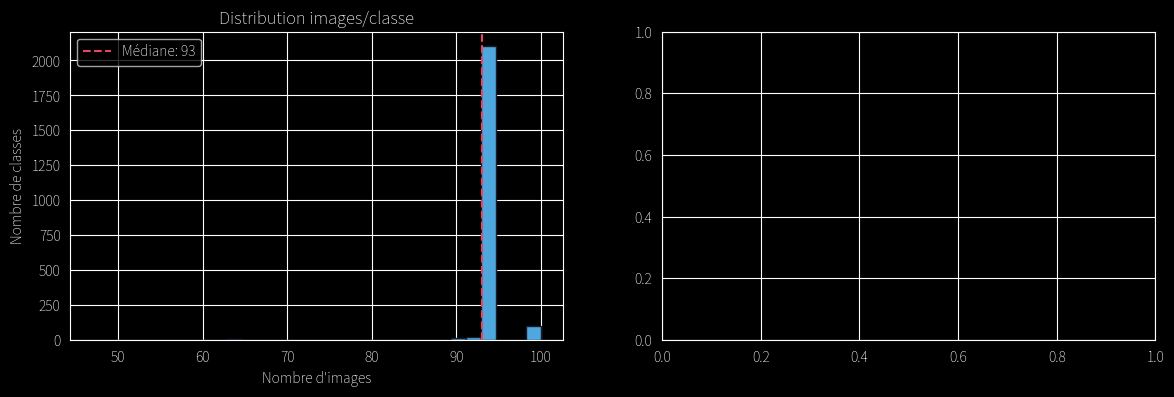

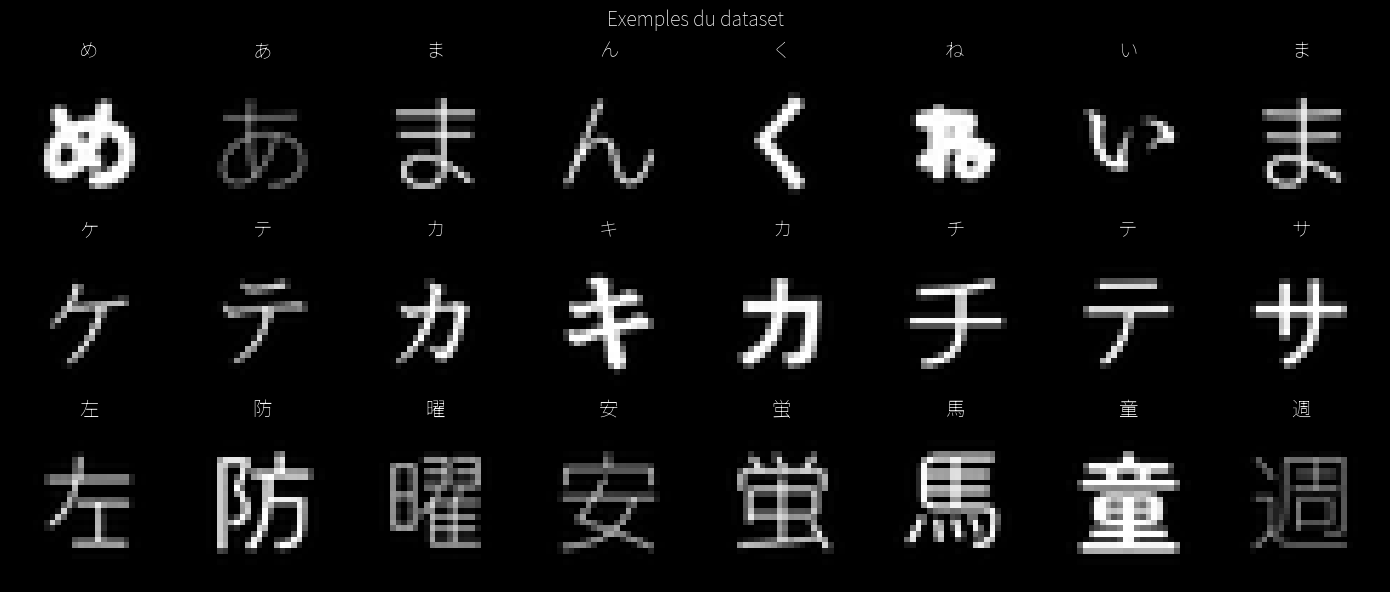

In [3]:
# Distribution du nombre d'images par classe
values = sorted(counts.values())
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(values, bins=30, color="#4ea8de", edgecolor="#1a1a2e")
axes[0].set_title("Distribution images/classe")
axes[0].set_xlabel("Nombre d'images")
axes[0].set_ylabel("Nombre de classes")
axes[0].axvline(np.median(values), color="#e94560", ls="--", label=f"Médiane: {np.median(values):.0f}")
axes[0].legend()

# Aperçu d'exemples par type
sample_indices = {"Hiragana": [], "Katakana": [], "Kanji": []}
for idx in np.random.choice(len(X_train), min(5000, len(X_train)), replace=False):
    lbl = y_train[idx]
    if lbl < 48 and len(sample_indices["Hiragana"]) < 8:
        sample_indices["Hiragana"].append(idx)
    elif 48 <= lbl < 96 and len(sample_indices["Katakana"]) < 8:
        sample_indices["Katakana"].append(idx)
    elif lbl >= 96 and len(sample_indices["Kanji"]) < 8:
        sample_indices["Kanji"].append(idx)

n_rows = len(sample_indices)
fig2, axes2 = plt.subplots(n_rows, 8, figsize=(14, n_rows * 2))
for row, (type_name, idxs) in enumerate(sample_indices.items()):
    for col in range(8):
        ax = axes2[row, col]
        if col < len(idxs):
            i = idxs[col]
            ax.imshow(X_train[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
            info = label_info[y_train[i]]
            ax.set_title(info["char"], fontsize=14)
        ax.axis("off")
    axes2[row, 0].set_ylabel(type_name, fontsize=12, rotation=0, labelpad=60)

fig2.suptitle("Exemples du dataset", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Soft labels & paires confusables

In [4]:
CONFUSABLE_PAIRS = [(28, 76)]  # へ (hiragana) ↔ ヘ (katakana)

_confusable_matrix = np.eye(NUM_CLASSES, dtype=np.float32)
for a, b in CONFUSABLE_PAIRS:
    if a < NUM_CLASSES and b < NUM_CLASSES:
        _confusable_matrix[a, a] = 0.5
        _confusable_matrix[a, b] = 0.5
        _confusable_matrix[b, b] = 0.5
        _confusable_matrix[b, a] = 0.5
_confusable_tf = tf.constant(_confusable_matrix)


def to_soft_label(y_scalar, label_smoothing=0.0):
    one_hot = tf.gather(_confusable_tf, y_scalar)
    if label_smoothing > 0:
        one_hot = one_hot * (1.0 - label_smoothing) + label_smoothing / NUM_CLASSES
    return one_hot

print(f"Paires confusables: {[(label_info[a]['char'], label_info[b]['char']) for a, b in CONFUSABLE_PAIRS if a < NUM_CLASSES]}")

Paires confusables: [('へ', 'ヘ')]


I0000 00:00:1774813531.228841   96677 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


## 4. Augmentation GPU-native & Mixup

In [5]:
def _bilinear_sample(image_2d, sy, sx):
    y0 = tf.cast(tf.floor(sy), tf.int32)
    x0 = tf.cast(tf.floor(sx), tf.int32)
    y1, x1 = y0 + 1, x0 + 1
    y0c = tf.clip_by_value(y0, 0, IMG_SIZE - 1)
    y1c = tf.clip_by_value(y1, 0, IMG_SIZE - 1)
    x0c = tf.clip_by_value(x0, 0, IMG_SIZE - 1)
    x1c = tf.clip_by_value(x1, 0, IMG_SIZE - 1)
    wy = sy - tf.cast(y0, tf.float32)
    wx = sx - tf.cast(x0, tf.float32)
    flat = tf.reshape(image_2d, [-1])
    def g(r, c): return tf.reshape(tf.gather(flat, tf.reshape(r * IMG_SIZE + c, [-1])), [IMG_SIZE, IMG_SIZE])
    return g(y0c, x0c)*(1-wy)*(1-wx) + g(y0c, x1c)*(1-wy)*wx + g(y1c, x0c)*wy*(1-wx) + g(y1c, x1c)*wy*wx


def _elastic(img):
    alpha = tf.random.uniform([], 0.6, 1.2)
    dx = tf.image.resize(tf.random.normal([1, 14, 14, 1]), [IMG_SIZE, IMG_SIZE], method='bilinear')[0, :, :, 0] * alpha
    dy = tf.image.resize(tf.random.normal([1, 14, 14, 1]), [IMG_SIZE, IMG_SIZE], method='bilinear')[0, :, :, 0] * alpha
    gy, gx = tf.meshgrid(tf.cast(tf.range(IMG_SIZE), tf.float32),
                          tf.cast(tf.range(IMG_SIZE), tf.float32), indexing='ij')
    S = tf.cast(IMG_SIZE - 1, tf.float32)
    return _bilinear_sample(img[:, :, 0],
                            tf.clip_by_value(gy + dy, 0.0, S),
                            tf.clip_by_value(gx + dx, 0.0, S))[:, :, tf.newaxis]


def _random_erase(img):
    h = tf.random.uniform([], 4, 12, dtype=tf.int32)
    w = tf.random.uniform([], 4, 12, dtype=tf.int32)
    top = tf.random.uniform([], 0, IMG_SIZE - h, dtype=tf.int32)
    left = tf.random.uniform([], 0, IMG_SIZE - w, dtype=tf.int32)
    hole = tf.pad(tf.zeros([h, w, 1], dtype=img.dtype),
                  [[top, IMG_SIZE - top - h], [left, IMG_SIZE - left - w], [0, 0]],
                  constant_values=1.0)
    return img * hole


def augment(image):
    img = tf.cast(image, tf.float32)
    img = tf.cond(tf.random.uniform([]) < 0.9, lambda: _elastic(img), lambda: img)
    angle = tf.random.uniform([], -25.0, 25.0) * (3.14159265 / 180.0)
    scale = tf.random.uniform([], 0.4, 1.6)
    ms = tf.minimum(0.30 / scale, 0.40)
    tx = tf.random.uniform([], -ms, ms) * tf.cast(IMG_SIZE, tf.float32)
    ty = tf.random.uniform([], -ms, ms) * tf.cast(IMG_SIZE, tf.float32)
    cos_a, sin_a = tf.cos(angle) / scale, tf.sin(angle) / scale
    c = (tf.cast(IMG_SIZE, tf.float32) - 1.0) / 2.0
    transform = tf.stack([cos_a, sin_a, c*(1-cos_a-sin_a) - tx/scale,
                          -sin_a, cos_a, c*(1+sin_a-cos_a) - ty/scale, 0.0, 0.0])
    img = tf.raw_ops.ImageProjectiveTransformV3(
        images=img[tf.newaxis], transforms=transform[tf.newaxis],
        output_shape=tf.constant([IMG_SIZE, IMG_SIZE]),
        fill_value=0.0, interpolation="BILINEAR", fill_mode="CONSTANT")[0]
    img = tf.cond(tf.random.uniform([]) < 0.3, lambda: _random_erase(img), lambda: img)
    img = tf.cond(tf.random.uniform([]) < 0.4,
                  lambda: tf.clip_by_value(img + tf.random.normal([IMG_SIZE, IMG_SIZE, 1],
                                           stddev=tf.random.uniform([], 0.01, 0.04)), 0.0, 1.0),
                  lambda: img)
    return img


def mixup(images, labels, alpha=MIXUP_ALPHA):
    bs = tf.shape(images)[0]
    # Gamma en float32 pour éviter les NaN en mixed precision
    lam = tf.random.gamma([bs, 1, 1, 1], alpha, beta=1.0 / alpha, dtype=tf.float32)
    lam2 = tf.random.gamma([bs, 1, 1, 1], alpha, beta=1.0 / alpha, dtype=tf.float32)
    lam = lam / tf.maximum(lam + lam2, 1e-8)  # éviter 0/0
    idx = tf.random.shuffle(tf.range(bs))
    images = tf.cast(images, tf.float32)
    lam_l = tf.reshape(lam, [bs, 1])
    mixed_images = images * lam + tf.gather(images, idx) * (1.0 - lam)
    mixed_labels = labels * lam_l + tf.gather(labels, idx) * (1.0 - lam_l)
    return mixed_images, mixed_labels

print("Augmentation et mixup définis.")

Augmentation et mixup définis.


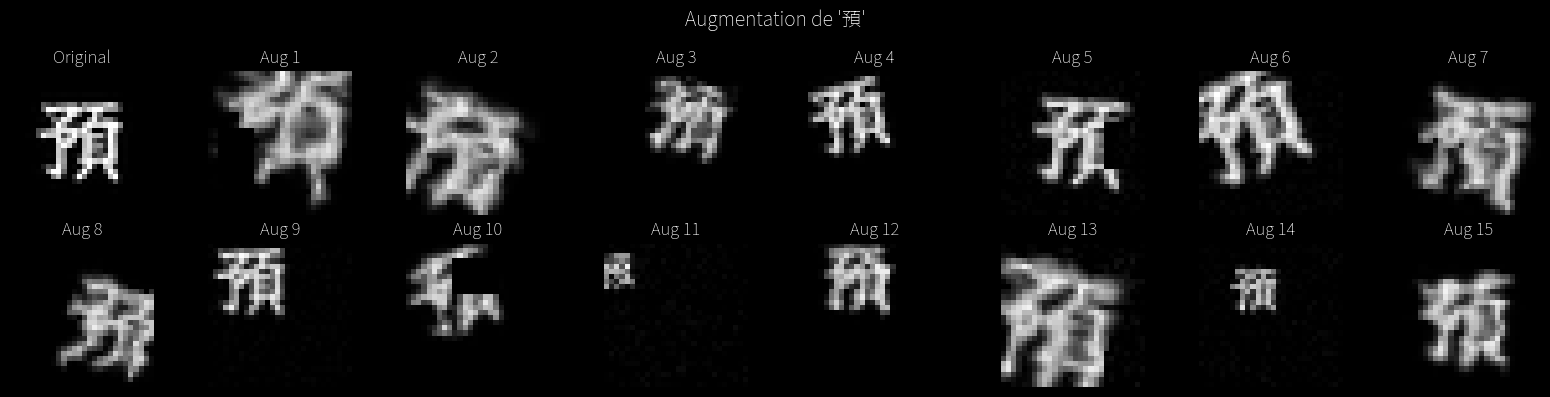

In [6]:
# Visualiser l'augmentation sur un exemple
sample_img = X_train[0]
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(sample_img[:, :, 0], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

for i in range(1, 16):
    ax = axes[i // 8, i % 8]
    aug = augment(sample_img).numpy()
    ax.imshow(aug[:, :, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Aug {i}")
    ax.axis("off")

plt.suptitle(f"Augmentation de '{label_info[y_train[0]]['char']}'", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Modèle — ResNet-18 + Attention

In [7]:
class StochasticDepth(layers.Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=None):
        if not training or self.drop_prob == 0.0:
            return x
        keep = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        return x / keep * tf.floor(keep + tf.random.uniform(shape, dtype=x.dtype))

    def get_config(self):
        return {**super().get_config(), "drop_prob": self.drop_prob}


def _res_block(x, filters, drop_prob=0.0, name="res"):
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same", use_bias=False, name=f"{name}_proj")(x)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.ReLU(name=f"{name}_relu1")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    if drop_prob > 0.0:
        x = StochasticDepth(drop_prob, name=f"{name}_drop")(x)
    x = layers.Add(name=f"{name}_add")([shortcut, x])
    x = layers.ReLU(name=f"{name}_relu2")(x)
    return x


def build_model(num_classes, img_size=28, stochastic_depth_rate=0.2):
    inputs = keras.Input(shape=(img_size, img_size, 1), name="input")
    x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="stem_conv")(inputs)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)

    total_blocks = 8
    drop_probs = [stochastic_depth_rate * i / (total_blocks - 1) for i in range(total_blocks)]
    bi = 0

    for i in range(2):
        x = _res_block(x, 64, drop_prob=drop_probs[bi], name=f"s1_b{i}"); bi += 1
    x = layers.MaxPooling2D(2, name="pool1")(x)
    for i in range(2):
        x = _res_block(x, 128, drop_prob=drop_probs[bi], name=f"s2_b{i}"); bi += 1
    x = layers.MaxPooling2D(2, name="pool2")(x)
    for i in range(2):
        x = _res_block(x, 256, drop_prob=drop_probs[bi], name=f"s3_b{i}"); bi += 1
    for i in range(2):
        x = _res_block(x, 512, drop_prob=drop_probs[bi], name=f"s4_b{i}"); bi += 1

    spatial = img_size // 4
    seq_len = spatial * spatial
    x = layers.Reshape((seq_len, 512), name="reshape_seq")(x)
    x = x + layers.Embedding(seq_len, 512, name="pos_embed")(tf.range(seq_len))
    attn = layers.MultiHeadAttention(num_heads=8, key_dim=64, dropout=0.1, name="mha")(x, x)
    x = layers.LayerNormalization(name="ln")(x + attn)

    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dense(1024, name="fc1")(x)
    x = layers.BatchNormalization(name="fc1_bn")(x)
    x = layers.ReLU(name="fc1_relu")(x)
    x = layers.Dropout(0.4, name="fc1_drop")(x)
    x = layers.Dense(num_classes, name="logits")(x)
    outputs = layers.Activation("softmax", dtype="float32", name="softmax")(x)
    return keras.Model(inputs, outputs, name="kanji_resnet")


model = build_model(num_classes=NUM_CLASSES)
model.summary()

Model: "kanji_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 28, 28,    │        576 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 28, 28,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 28, 28,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_conv1         │ (None, 28, 28,    │     36,864 │ stem_relu[0][0]   │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_bn1           │ (None, 28, 28,    │        256 │ s1_b0_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_relu1 (ReLU)  │ (None, 28, 28,    │          0 │ s1_b0_bn1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_conv2         │ (None, 28, 28,    │     36,864 │ s1_b0_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_bn2           │ (None, 28, 28,    │        256 │ s1_b0_conv2[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_add (Add)     │ (None, 28, 28,    │          0 │ stem_relu[0][0],  │
│                     │ 64)               │            │ s1_b0_bn2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b0_relu2 (ReLU)  │ (None, 28, 28,    │          0 │ s1_b0_add[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv1         │ (None, 28, 28,    │     36,864 │ s1_b0_relu2[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn1           │ (None, 28, 28,    │        256 │ s1_b1_conv1[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_relu1 (ReLU)  │ (None, 28, 28,    │          0 │ s1_b1_bn1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv2         │ (None, 28, 28,    │     36,864 │ s1_b1_relu1[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn2           │ (None, 28, 28,    │        256 │ s1_b1_conv2[0][0] │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_drop          │ (None, 28, 28,    │          0 │ s1_b1_bn2[0][0]   │
│ (StochasticDepth)   │ 64)               │            │                 

 Total params: 15,046,136 (57.40 MB)

 Trainable params: 15,034,488 (57.35 MB)

 Non-trainable params: 11,648 (45.50 KB)

## 6. Compilation & entraînement

In [ ]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-6, decay_steps=total_steps - warmup_steps,
    alpha=1e-6, warmup_target=0.001, warmup_steps=warmup_steps,
)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=lr_schedule, weight_decay=0.01, clipnorm=1.0),
    loss="categorical_crossentropy", metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=30, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "best_model.keras"),
        monitor="val_accuracy", save_best_only=True, verbose=1),
]

# Pipeline tf.data
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = (train_ds
    .shuffle(len(X_train), reshuffle_each_iteration=True)
    .map(lambda x, y: (augment(x), to_soft_label(y, LABEL_SMOOTHING)),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .map(lambda x, y: mixup(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE))

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = (val_ds
    .map(lambda x, y: (x, to_soft_label(y)), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE))

print(f"Steps/epoch: {steps_per_epoch} | Total steps: {total_steps}")

In [ ]:
history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=callbacks, verbose=1)

## 7. Courbes d'entraînement

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="Train", color="#e94560")
ax1.plot(history.history["val_loss"], label="Val", color="#4ea8de")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history["accuracy"], label="Train", color="#e94560")
ax2.plot(history.history["val_accuracy"], label="Val", color="#4ea8de")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

best_val = max(history.history["val_accuracy"])
fig.suptitle(f"Meilleure val_accuracy: {best_val:.4f}", fontsize=13)
fig.tight_layout()
fig.savefig(str(PLOTS_DIR / "training_final.png"), dpi=150)
plt.show()

## 8. Évaluation sur le test set

In [11]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = (test_ds
    .map(lambda x, y: (x, to_soft_label(y)), num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

top5 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-5:] for i in range(len(y_test))])
print(f"Top-5 accuracy: {top5:.4f}")

hira_mask = y_test < 48
kata_mask = (y_test >= 48) & (y_test < 96)
print(f"Hiragana: {np.mean(y_pred[hira_mask] == y_test[hira_mask]):.4f}")
print(f"Katakana: {np.mean(y_pred[kata_mask] == y_test[kata_mask]):.4f}")
if NUM_CLASSES > 96:
    kanji_mask = y_test >= 96
    if kanji_mask.any():
        print(f"Kanji:    {np.mean(y_pred[kanji_mask] == y_test[kanji_mask]):.4f}")

2026-03-29 22:01:58.084356: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 44 bytes spill stores, 44 bytes spill loads

2026-03-29 22:01:58.268212: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 204 bytes spill stores, 572 bytes spill loads

2026-03-29 22:01:59.456039: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 376 bytes spill stores, 332 bytes spill loads

2026-03-29 22:01:59.839390: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_714_0', 384 bytes spill stores, 332 bytes spill loads

2026-03-29 22:02:00.580540: I external/loc

Test loss: 0.4520 | Test accuracy: 0.9242


2026-03-29 22:02:10.496106: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 8 bytes spill stores, 8 bytes spill loads

2026-03-29 22:02:11.517918: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 44 bytes spill stores, 44 bytes spill loads

2026-03-29 22:02:11.818670: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6', 204 bytes spill stores, 572 bytes spill loads

2026-03-29 22:02:12.139141: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3_0', 384 bytes spill stores, 332 bytes spill loads

2026-03-29 22:02:12.633746: I external/local_xla

Top-5 accuracy: 0.9768
Hiragana: 0.8583
Katakana: 0.8042
Kanji:    0.9281


## 9. Top 20 classes les plus difficiles

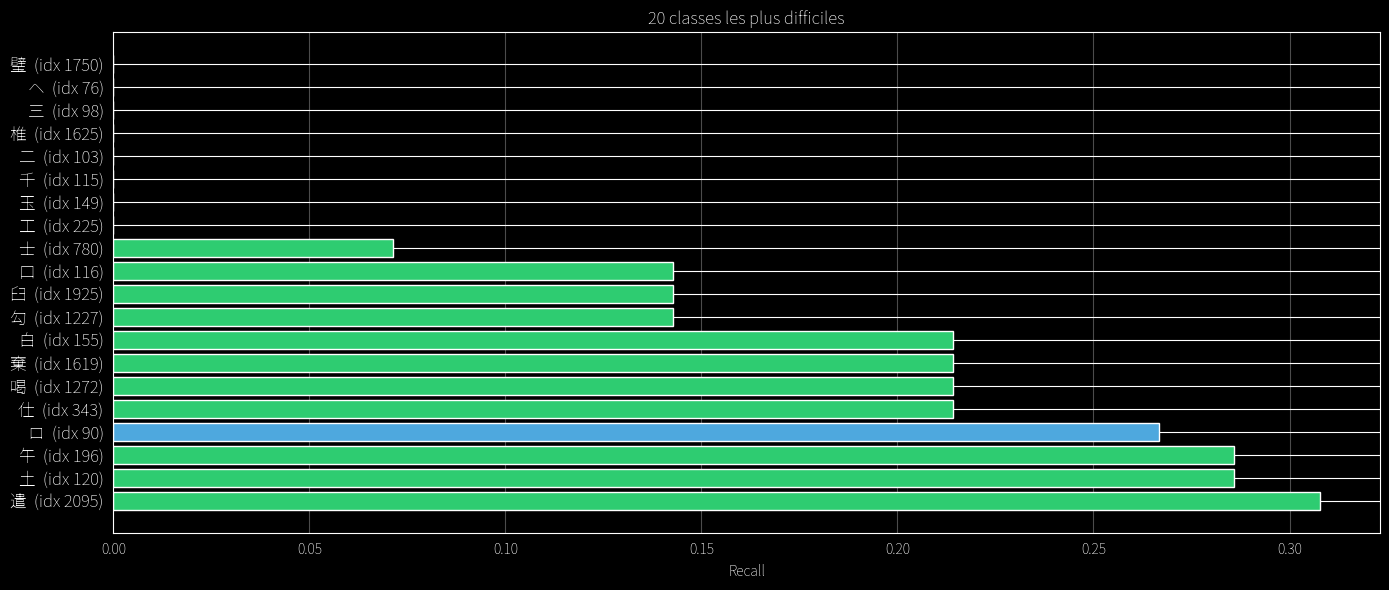

  璧 (recall=0.00) confondu avec: [('壁', np.int64(13))]
  ヘ (recall=0.00) confondu avec: [('へ', np.int64(15))]
  三 (recall=0.00) confondu avec: [('ミ', np.int64(10)), ('ニ', np.int64(3)), ('巨', np.int64(1))]
  椎 (recall=0.00) confondu avec: [('稚', np.int64(13)), ('催', np.int64(1))]
  二 (recall=0.00) confondu avec: [('ニ', np.int64(8)), ('ミ', np.int64(3)), ('ヱ', np.int64(1))]


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=range(NUM_CLASSES))
per_class_recall = np.where(cm.sum(axis=1) > 0,
                            cm.diagonal() / cm.sum(axis=1), 1.0)

worst_20 = np.argsort(per_class_recall)[:20]
fig, ax = plt.subplots(figsize=(14, 6))
chars = [label_info[i]["char"] for i in worst_20]
recalls = [per_class_recall[i] for i in worst_20]
colors = ["#e94560" if i < 48 else "#4ea8de" if i < 96 else "#2ecc71" for i in worst_20]

ax.barh(range(len(worst_20)), recalls, color=colors)
ax.set_yticks(range(len(worst_20)))
ax.set_yticklabels([f"{chars[j]}  (idx {worst_20[j]})" for j in range(len(worst_20))], fontsize=12)
ax.set_xlabel("Recall")
ax.set_title("20 classes les plus difficiles")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Afficher les confusions principales pour le top 5
for idx in worst_20[:5]:
    confused_with = np.argsort(cm[idx])[-3:][::-1]
    info = label_info[idx]
    confusions = [(label_info[c]["char"], cm[idx, c]) for c in confused_with if cm[idx, c] > 0]
    print(f"  {info['char']} (recall={per_class_recall[idx]:.2f}) confondu avec: {confusions}")

## 10. Exemples d'erreurs

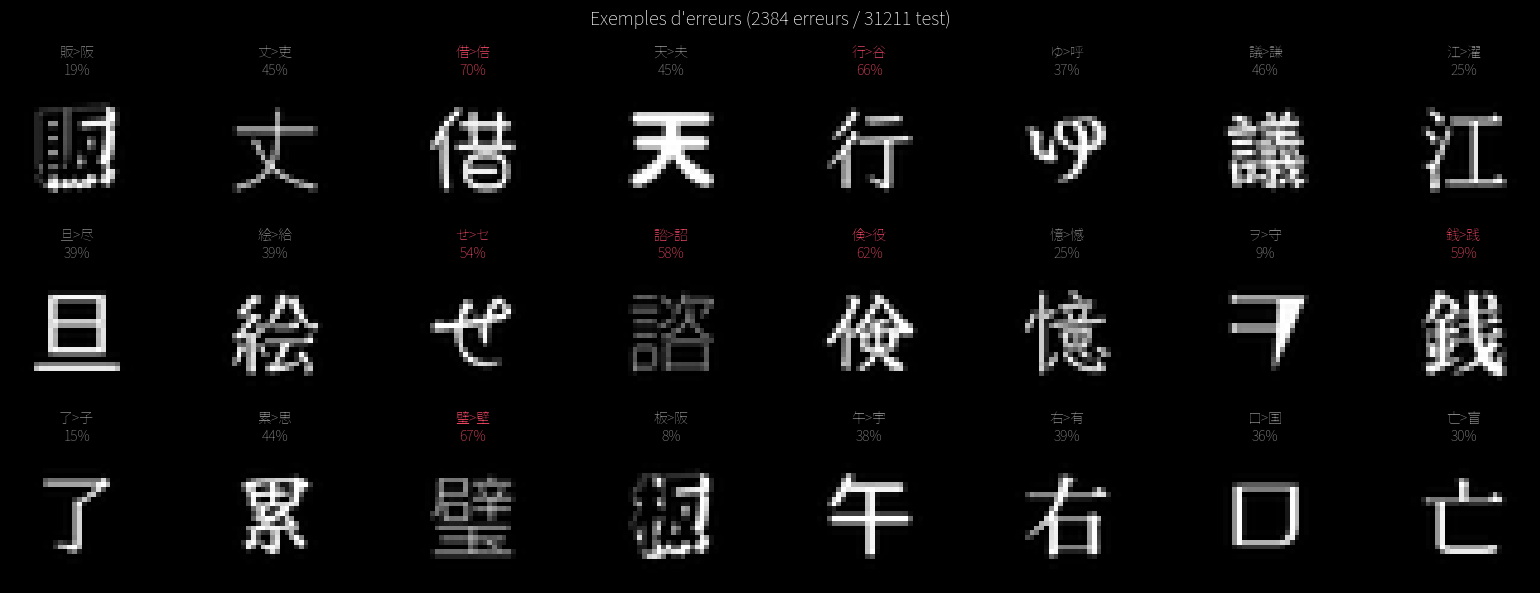

In [13]:
errors = np.where(y_pred != y_test)[0]
n_show = min(24, len(errors))
sample_errors = np.random.choice(errors, n_show, replace=False)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, idx in enumerate(sample_errors):
    ax = axes[i // 8, i % 8]
    ax.imshow(X_test[idx, :, :, 0], cmap="gray", vmin=0, vmax=1)
    true_char = label_info[y_test[idx]]["char"]
    pred_char = label_info[y_pred[idx]]["char"]
    conf = y_pred_proba[idx, y_pred[idx]]
    ax.set_title(f"{true_char}>{pred_char}\n{conf:.0%}", fontsize=10,
                 color="#e94560" if conf > 0.5 else "#888")
    ax.axis("off")

for i in range(n_show, 24):
    axes[i // 8, i % 8].axis("off")

fig.suptitle(f"Exemples d'erreurs ({len(errors)} erreurs / {len(y_test)} test)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Matrice de confusion (kana uniquement)

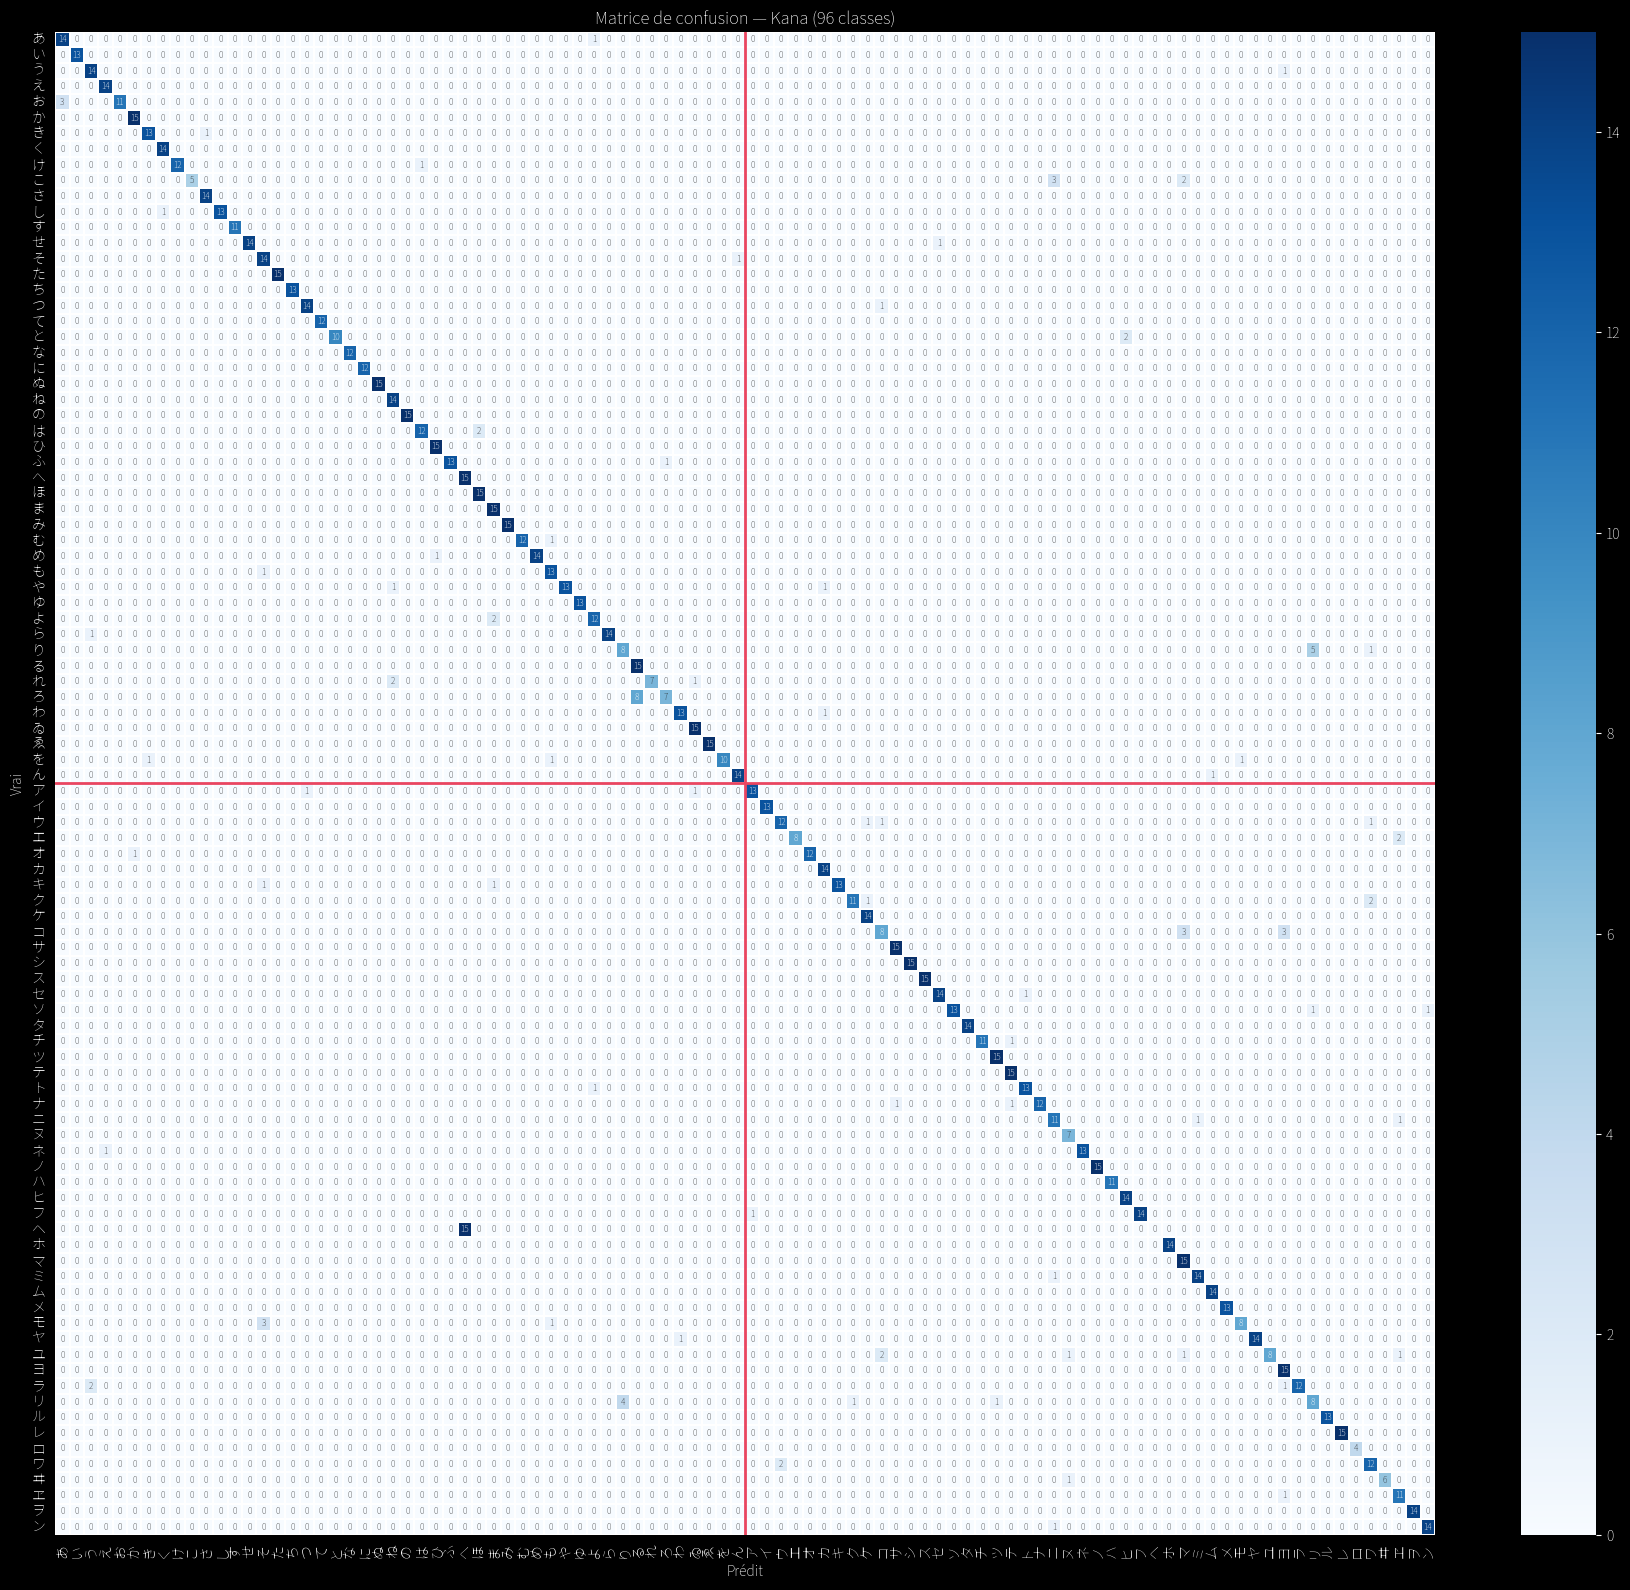

In [14]:
# Matrice de confusion sur les 96 kana (trop de classes pour afficher les 2232)
kana_mask = y_test < 96
cm_kana = confusion_matrix(y_test[kana_mask], y_pred[kana_mask], labels=range(96))
kana_chars = [label_info[i]["char"] for i in range(96)]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm_kana, xticklabels=kana_chars, yticklabels=kana_chars,
            cmap="Blues", fmt="d", annot=True, annot_kws={"size": 6},
            linewidths=0.3, ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Vrai")
ax.set_title("Matrice de confusion — Kana (96 classes)")

# Ligne de séparation hiragana/katakana
ax.axhline(48, color="#e94560", linewidth=2)
ax.axvline(48, color="#e94560", linewidth=2)

plt.tight_layout()
plt.show()

## 12. Sauvegarde

In [15]:
model.save(str(MODELS_DIR / "final_model.keras"))
print(f"Modèles sauvegardés dans {MODELS_DIR}/")
print(f"  best_model.keras  (meilleure val_accuracy)")
print(f"  final_model.keras (dernier epoch)")
print(f"\nRésumé :")
print(f"  Test accuracy:  {test_acc:.4f}")
print(f"  Top-5 accuracy: {top5:.4f}")
print(f"  Classes: {NUM_CLASSES}")

Modèles sauvegardés dans models/
  best_model.keras  (meilleure val_accuracy)
  final_model.keras (dernier epoch)

Résumé :
  Test accuracy:  0.9242
  Top-5 accuracy: 0.9768
  Classes: 2232
